## Amazon Sales Data 


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df = pd.read_csv("Amazon Sale Report.csv")
df.head()

C:\Users\yunus emre\AppData\Local\Temp\ipykernel_19720\3949281228.py:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Amazon Sale Report.csv")


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [50]:
df.shape

(128975, 24)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [52]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [53]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ","_")
    .str.replace("-","_")
)
df.columns


Index(['index', 'order_id', 'date', 'status', 'fulfilment', 'sales_channel',
       'ship_service_level', 'style', 'sku', 'category', 'size', 'asin',
       'courier_status', 'qty', 'currency', 'amount', 'ship_city',
       'ship_state', 'ship_postal_code', 'ship_country', 'promotion_ids',
       'b2b', 'fulfilled_by', 'unnamed:_22'],
      dtype='object')

In [54]:
df.columns

Index(['index', 'order_id', 'date', 'status', 'fulfilment', 'sales_channel',
       'ship_service_level', 'style', 'sku', 'category', 'size', 'asin',
       'courier_status', 'qty', 'currency', 'amount', 'ship_city',
       'ship_state', 'ship_postal_code', 'ship_country', 'promotion_ids',
       'b2b', 'fulfilled_by', 'unnamed:_22'],
      dtype='object')

In [55]:
df.drop(columns="unnamed:_22",inplace=True)

In [56]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   order_id            128975 non-null  object 
 2   date                128975 non-null  object 
 3   status              128975 non-null  object 
 4   fulfilment          128975 non-null  object 
 5   sales_channel       128975 non-null  object 
 6   ship_service_level  128975 non-null  object 
 7   style               128975 non-null  object 
 8   sku                 128975 non-null  object 
 9   category            128975 non-null  object 
 10  size                128975 non-null  object 
 11  asin                128975 non-null  object 
 12  courier_status      122103 non-null  object 
 13  qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  amount              121180 non-nul

In [57]:
missing = (
    df.isnull().sum()
    .sort_values(ascending=False)
)
missing

fulfilled_by          89698
promotion_ids         49153
amount                 7795
currency               7795
courier_status         6872
ship_country             33
ship_postal_code         33
ship_state               33
ship_city                33
b2b                       0
qty                       0
index                     0
order_id                  0
size                      0
category                  0
sku                       0
style                     0
ship_service_level        0
sales_channel             0
fulfilment                0
status                    0
date                      0
asin                      0
dtype: int64

In [58]:
df.describe()

,index,qty,amount,ship_postal_code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


In [59]:
print("duplicated rows",df.duplicated().sum())

duplicated rows 0


### Data Cleaning

In [60]:
missing_values =(
    df.isnull().sum()
    .sort_values(ascending=False)
    .to_frame("Missing Values")   
)
missing_values

,Missing Values
fulfilled_by,89698
promotion_ids,49153
amount,7795
currency,7795
courier_status,6872
ship_country,33
ship_postal_code,33
ship_state,33
ship_city,33
b2b,0


In [61]:
df["date"] = pd.to_datetime(df["date"])

C:\Users\yunus emre\AppData\Local\Temp\ipykernel_19720\3228555721.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"])


In [62]:
df["date"].head()

0   2022-04-30
1   2022-04-30
2   2022-04-30
3   2022-04-30
4   2022-04-30
Name: date, dtype: datetime64[ns]

In [63]:
df["amount"] = df["amount"].fillna(df["amount"].median())

In [64]:
df["currency"] = df["currency"].fillna("Unknown")

In [65]:
print("Duplicate Rows",df.duplicated().sum())

Duplicate Rows 0


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   index               128975 non-null  int64         
 1   order_id            128975 non-null  object        
 2   date                128975 non-null  datetime64[ns]
 3   status              128975 non-null  object        
 4   fulfilment          128975 non-null  object        
 5   sales_channel       128975 non-null  object        
 6   ship_service_level  128975 non-null  object        
 7   style               128975 non-null  object        
 8   sku                 128975 non-null  object        
 9   category            128975 non-null  object        
 10  size                128975 non-null  object        
 11  asin                128975 non-null  object        
 12  courier_status      122103 non-null  object        
 13  qty                 128975 no

In [67]:
df["year"] = df["date"].dt.year
df["Month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()
df["Day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.day_name()

In [68]:
df[["date","month_name","day_of_week"]].head()

,date,month_name,day_of_week
0,2022-04-30,April,Saturday
1,2022-04-30,April,Saturday
2,2022-04-30,April,Saturday
3,2022-04-30,April,Saturday
4,2022-04-30,April,Saturday


In [69]:
print("Dataset Shape",df.shape)

df.head()

Dataset Shape (128975, 28)


,index,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,...,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,year,Month,month_name,Day,day_of_week
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,400081.0,IN,NaN,False,Easy Ship,2022,4,April,30,Saturday
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,2022,4,April,30,Saturday
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,2022,4,April,30,Saturday
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,605008.0,IN,NaN,False,Easy Ship,2022,4,April,30,Saturday
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,600073.0,IN,NaN,False,NaN,2022,4,April,30,Saturday


## Exploratory Data Analysis (EDA)

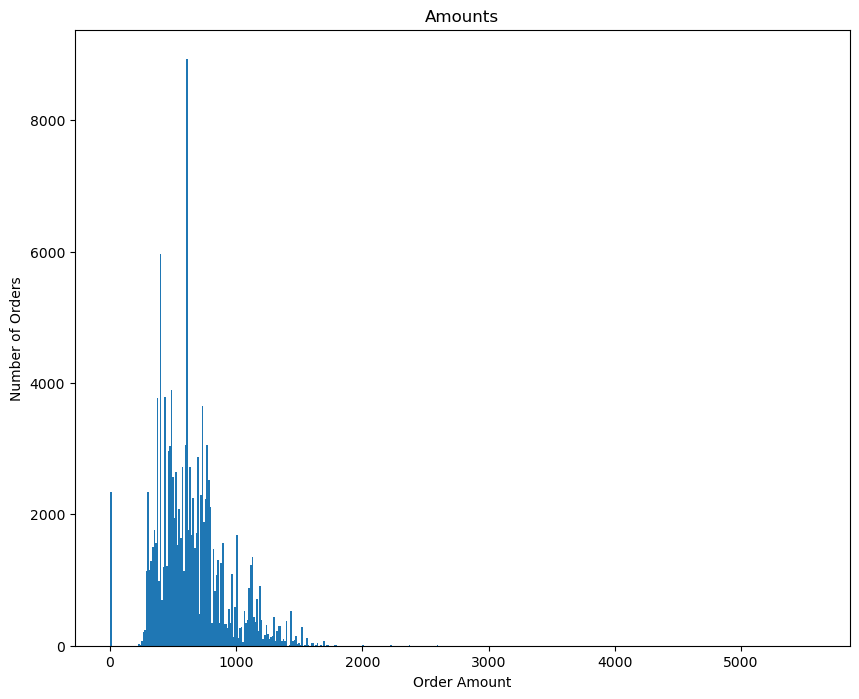

In [70]:
plt.figure(figsize=(10,8))
plt.hist(df["amount"],bins="auto")
plt.title("Amounts")
plt.xlabel("Order Amount")
plt.ylabel("Number of Orders")

plt.show()

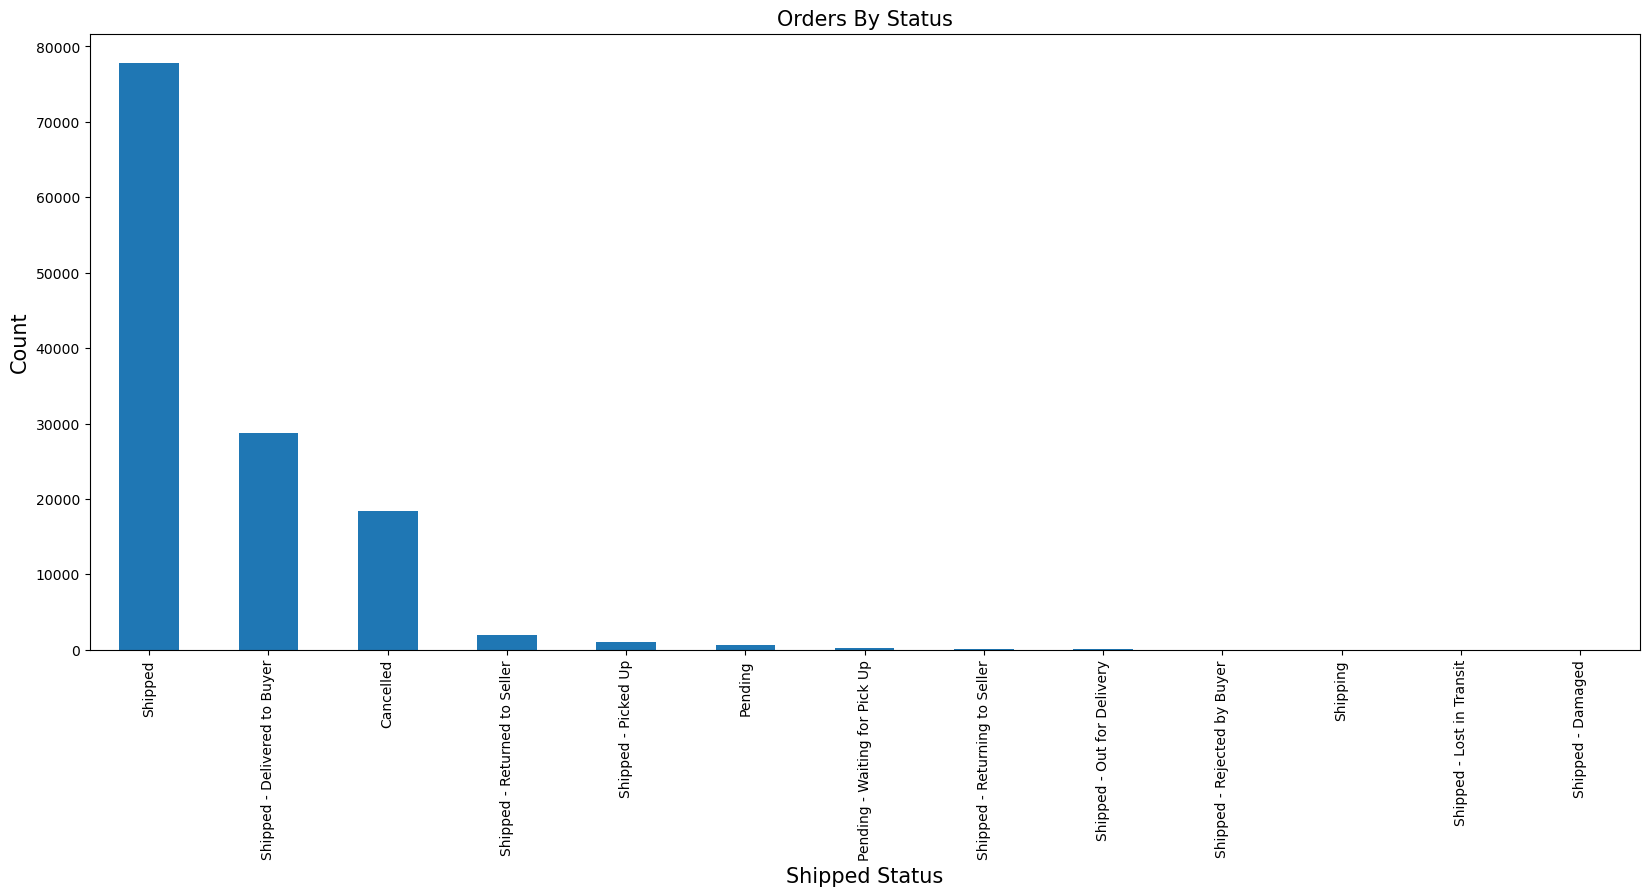

In [71]:
plt.figure(figsize=(20,8))
df["status"].value_counts().plot(kind="bar")
plt.title("Orders By Status",fontsize=15)
plt.xlabel("Shipped Status",fontsize=15)
plt.ylabel("Count",fontsize=15)
plt.xticks(rotation = 90)

plt.show()

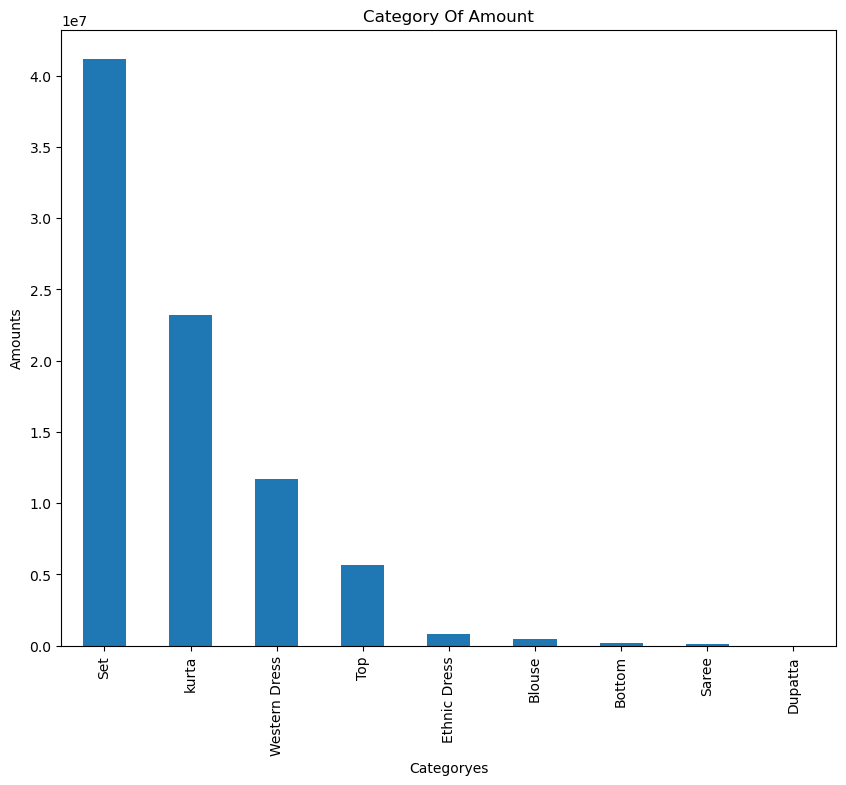

In [72]:
category_sales = (
    df.groupby("category")["amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,8))
category_sales.plot(kind="bar")
plt.title("Category Of Amount")
plt.xlabel("Categoryes")
plt.ylabel("Amounts")

plt.show()

In [73]:
df.columns

Index(['index', 'order_id', 'date', 'status', 'fulfilment', 'sales_channel',
       'ship_service_level', 'style', 'sku', 'category', 'size', 'asin',
       'courier_status', 'qty', 'currency', 'amount', 'ship_city',
       'ship_state', 'ship_postal_code', 'ship_country', 'promotion_ids',
       'b2b', 'fulfilled_by', 'year', 'Month', 'month_name', 'Day',
       'day_of_week'],
      dtype='object')

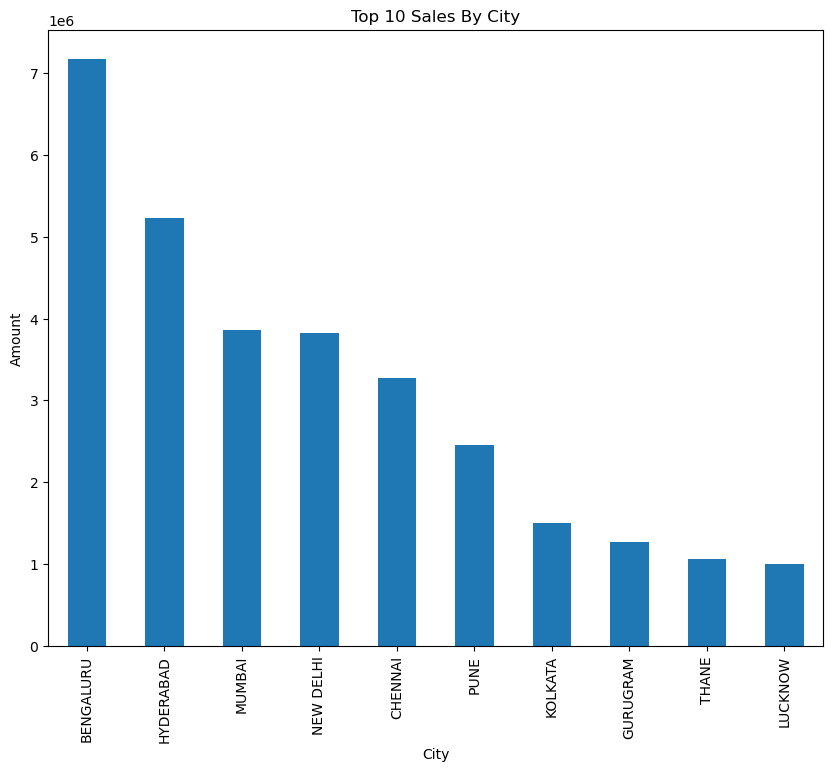

In [74]:
top_city = (
    df.groupby("ship_city")["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(10,8))
top_city.plot(kind="bar")
plt.title("Top 10 Sales By City")
plt.xlabel("City")
plt.ylabel("Amount")

plt.show()

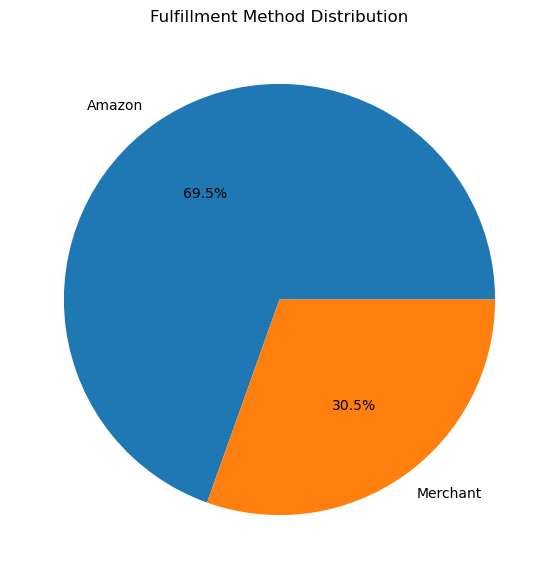

In [79]:
plt.figure(figsize=(7,7))

df["fulfilment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Fulfillment Method Distribution")

plt.show()


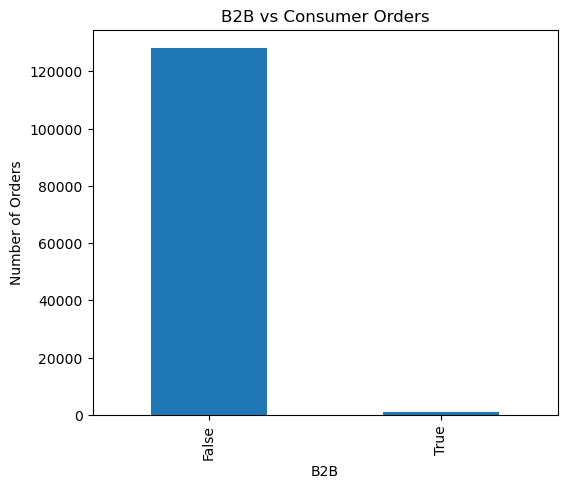

In [80]:
plt.figure(figsize=(6,5))

df["b2b"].value_counts().plot(kind="bar")

plt.title("B2B vs Consumer Orders")
plt.xlabel("B2B")
plt.ylabel("Number of Orders")

plt.show()

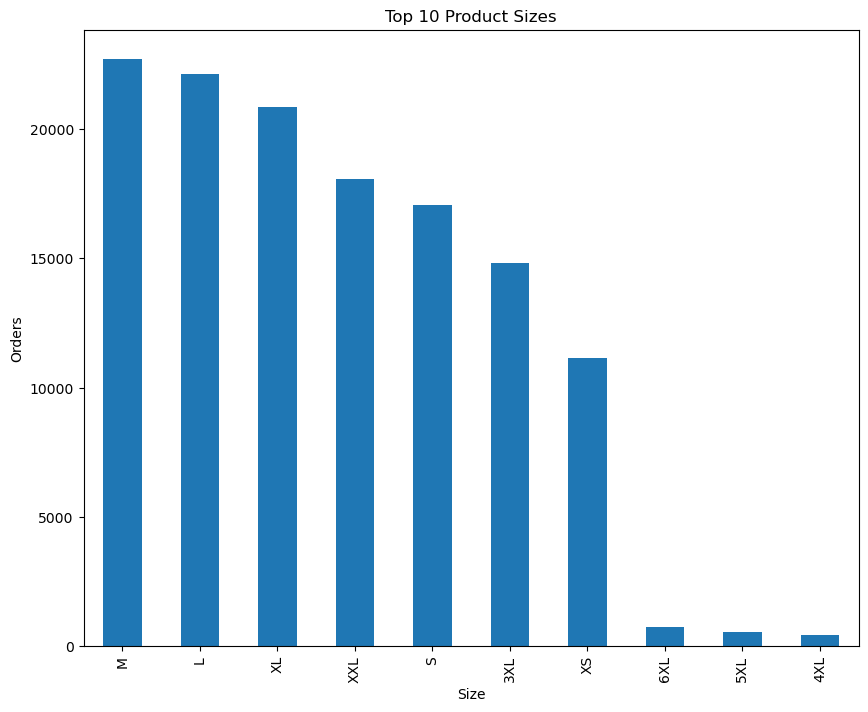

In [82]:
plt.figure(figsize=(10,8))
df["size"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Product Sizes")
plt.xlabel("Size")
plt.ylabel("Orders")

plt.show()

In [83]:
df.columns

Index(['index', 'order_id', 'date', 'status', 'fulfilment', 'sales_channel',
       'ship_service_level', 'style', 'sku', 'category', 'size', 'asin',
       'courier_status', 'qty', 'currency', 'amount', 'ship_city',
       'ship_state', 'ship_postal_code', 'ship_country', 'promotion_ids',
       'b2b', 'fulfilled_by', 'year', 'Month', 'month_name', 'Day',
       'day_of_week'],
      dtype='object')

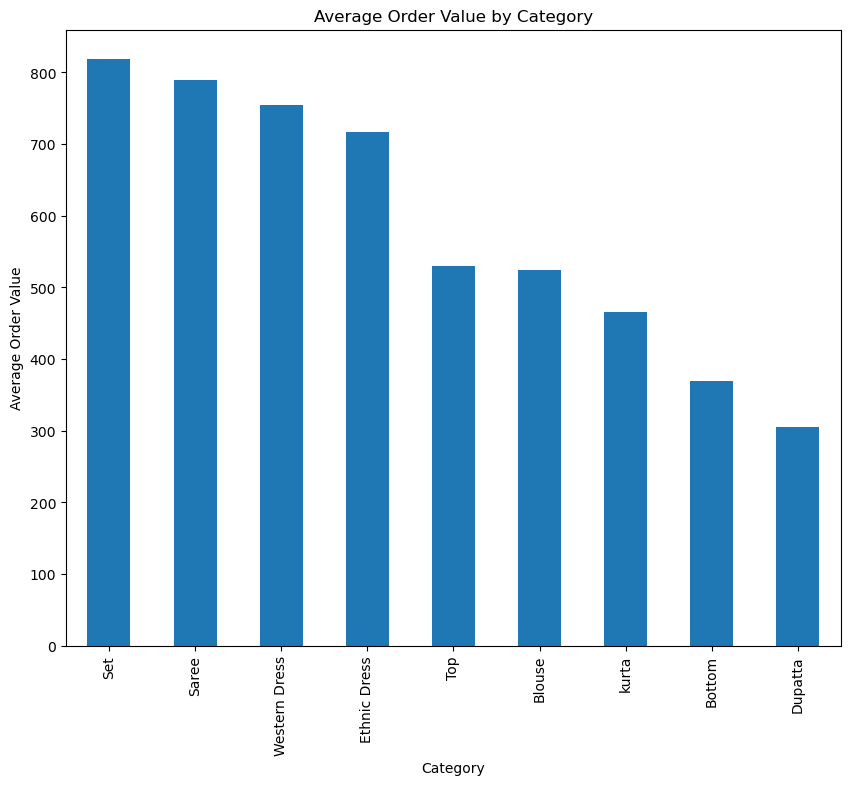

In [84]:
avarage_sales = (
    df.groupby("category")["amount"].mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,8))
avarage_sales.plot(kind="bar")
plt.title("Average Order Value by Category")
plt.xlabel("Category")
plt.ylabel("Average Order Value")

plt.show()


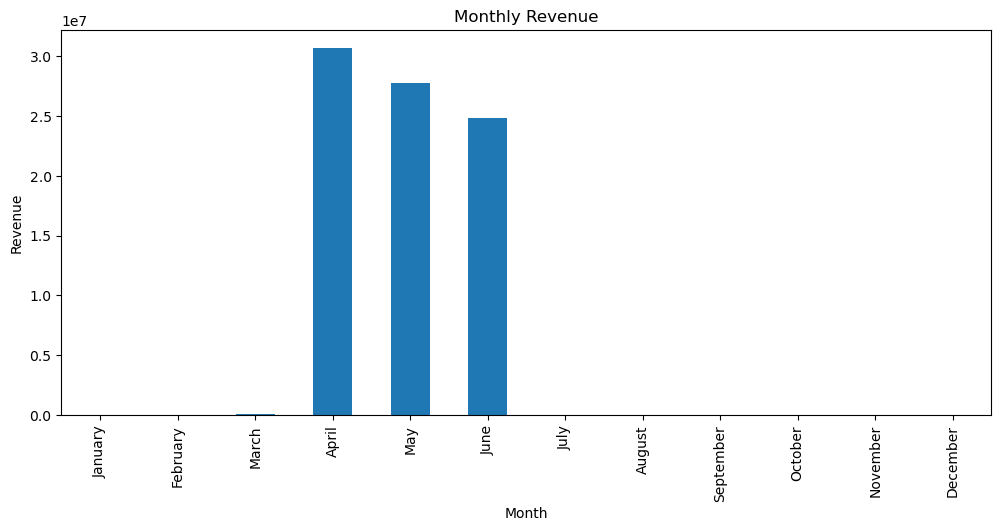

In [85]:
monthly_sales = (
    df.groupby("month_name")["amount"]
      .sum()
)

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,5))

monthly_sales.plot(kind="bar")

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

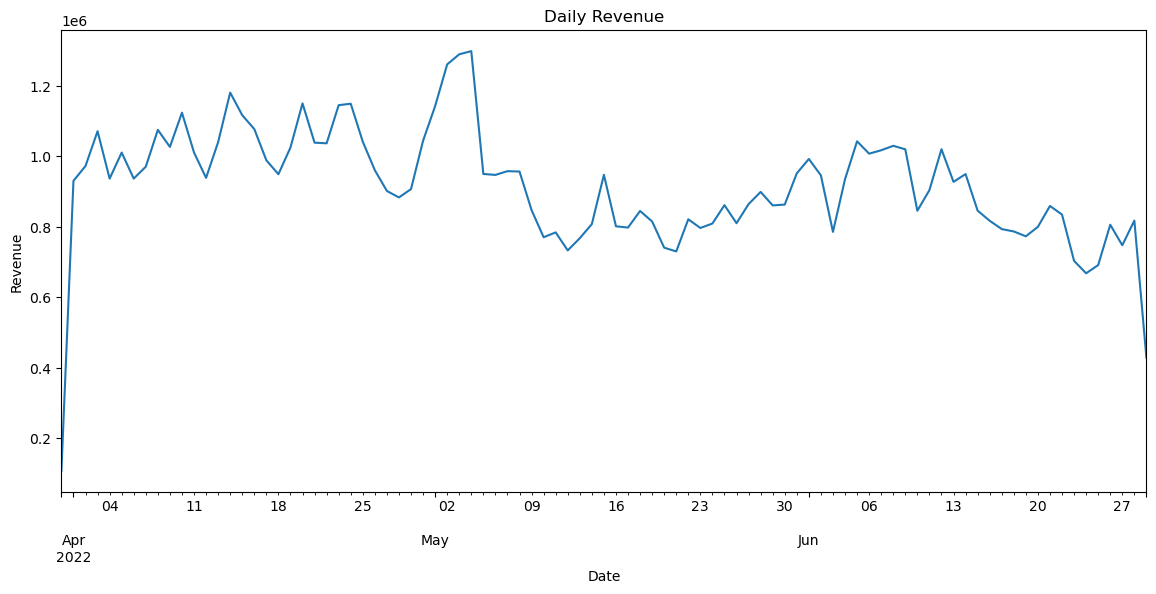

In [86]:
daily_sales = (
    df.groupby("date")["amount"]
      .sum()
)

plt.figure(figsize=(14,6))

daily_sales.plot()

plt.title("Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

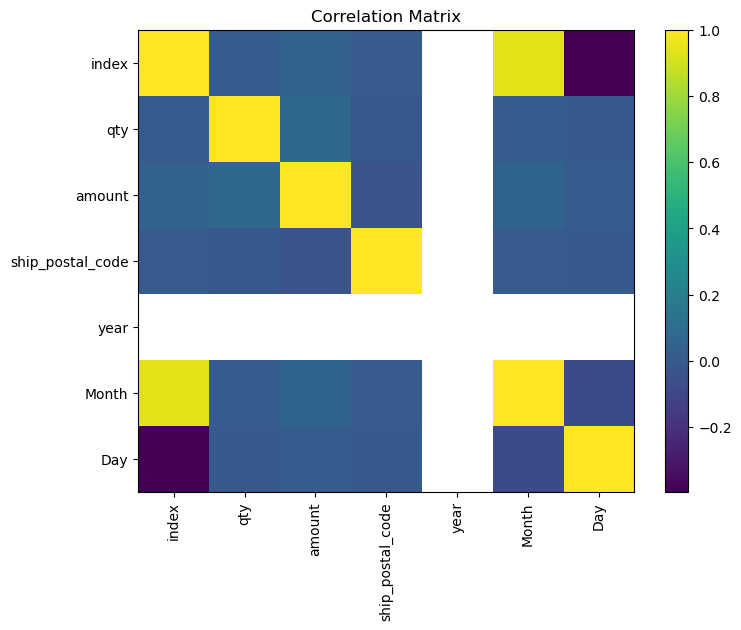

In [87]:
numeric = df.select_dtypes(include="number")

corr = numeric.corr()

plt.figure(figsize=(8,6))

plt.imshow(corr, aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

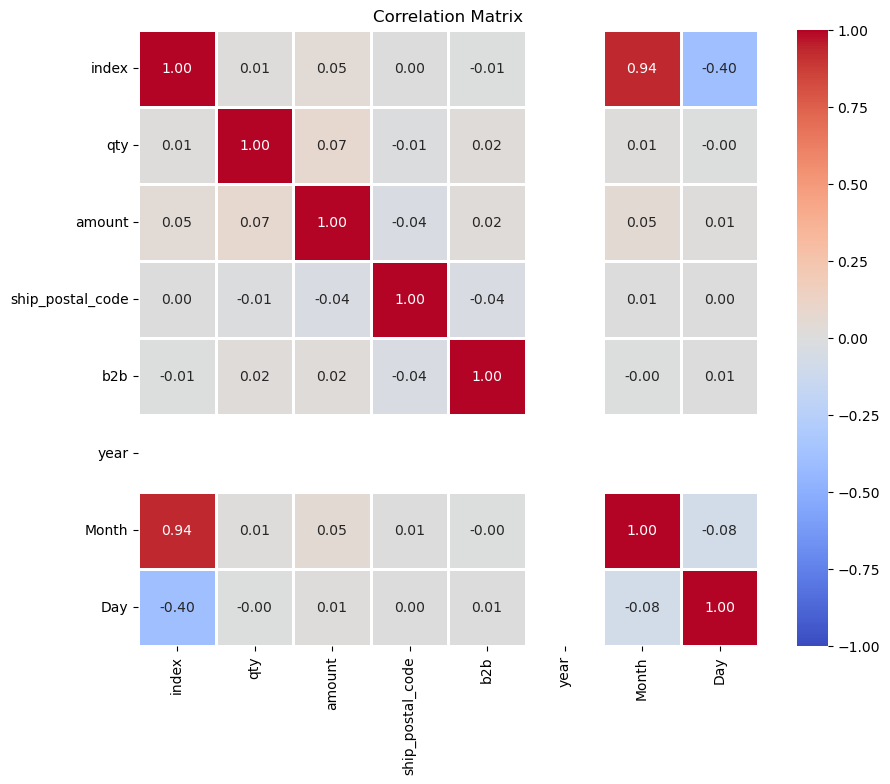

In [92]:
plt.figure(figsize=(10,8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    data=corr_matrix,
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.8
)

plt.title("Correlation Matrix")
plt.show()